# __R2.06 Exploitation d'une base de données - 2e partie : visualisation__

===============  Notebook #3 : Pandas et Matplotlib


Vous pouvez d'ores et déjà ouvrir la [documentation de la fonction pandas.DataFrame.plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html) pour la conserver dans un coin sécurisé de votre navigateur préféré...

# 1re partie : données issues de la base HTSplus

Import des bibliothèques

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlalchemy as sa
from IPython.display import display

Connexion à la base _HTSplus_

In [3]:
# connexion à la base HTSplus
psw = input("Mot de passe du compte ETD :")

server = "info-mssql-etd"
user = "ETD"
database = "HTSplus"
engine = sa.create_engine(f'mssql+pymssql://{user}:{psw}@{server}/{database}')
cnxn = engine.connect()


Mot de passe du compte ETD : ETD


__Exercice 1.0.__ Importer les tables _T_ELEVE_ELV_ et _T_CLASSES_CLS_ dans des dataframes `df_eleves` et `df_classes` et afficher les 4 premieres lignes de chaque dataframe

In [4]:
sql_eleve = "select * from T_ELEVE_ELV"
sql_classe = "select * from T_CLASSE_CLS"
df_eleve = pd.read_sql(sql_eleve, cnxn, coerce_float=False)
df_classe = pd.read_sql(sql_classe, cnxn, coerce_float=False)

display(df_eleve.head(4))
display(df_classe.head(4))

,ELV_Id,ELV_REF_ELV,ELV_REF_CLS,ELV_Nom,ELV_AnneeNais,ELV_VilleNais
0,3,989,9,Thomas,2000,Troyes
1,7,598,9,Scott,1998,Solliès-Pont
2,8,368,9,Hubert,1977,Hennebont
3,10,475,84,Thaddeus,1995,Hampigny


,CLS_Num,CLS_Intit
0,40,Atome
1,51,Baryon
2,52,Boson
3,25,Électron


Le résultat obtenu devrait ressembler à ceci :

![elevesEtClasses.png](images6/elevesEtClasses.png) 

__Exercice 1.1.__  Créer un dataframe `df_elevesBis`, composé des trois séries _ELV_Nom_, _ELV_AnneeNais_ et _CLS_Intit_ permettant d'associer chaque élève à sa classe, en conservant la classe sans élèves (ne pas hésiter à consulter la [documentation de la fonction _pandas.DataFrame.merge_](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)) et en afficher les 4 dernières lignes.

In [6]:
df_elevesBis = df_eleve.merge(df_classe, how='right', left_on='ELV_REF_CLS', right_on='CLS_Num')[['ELV_Nom', 'ELV_AnneeNais', 'CLS_Intit']]
df_elevesBis.tail(4)

,ELV_Nom,ELV_AnneeNais,CLS_Intit
607,Hobart,1990,Z0
608,Tadeas,1995,Z0
609,Thordis,1977,Z0
610,Tertias,1989,Z0


Le résultat obtenu devrait ressembler à ceci :

![elevesBis.png](images6/elevesBis.png) 

__Exercice 1.2.__  Créer un dataframe `df_donnees`, à partir du dataframe _df_elevesBis_, permettant de connaître le nombre d'élèves par classe, trié par nombre d'élèves décroissant. 
(Note : la fonction _rename_ permet de renommer une colonne.)

Afficher son contenu.

In [33]:
df_donnees = df_eleves_Bis.groupby("CLS_Intit")
df_donnees = df_donnees.count()[["ELV_Id"]].rename(columns={"ELV_Id": "nb élèves"})
df_donnees = df_donnees.sort_values(by=['nb élèves'], ascending=False)
df_donnees.tail(5)

,nb élèves
CLS_Intit,
Nucléon,23
Proton,22
Hadron,21
Électron,17
Quark,0


Le résultat obtenu devrait se terminer ainsi :

![nbEleves.png](images6/nbEleves.png) 

__Exercice 1.3.__  Créer un diagramme à barres (verticales) à partir du dataframe _df_donnees_

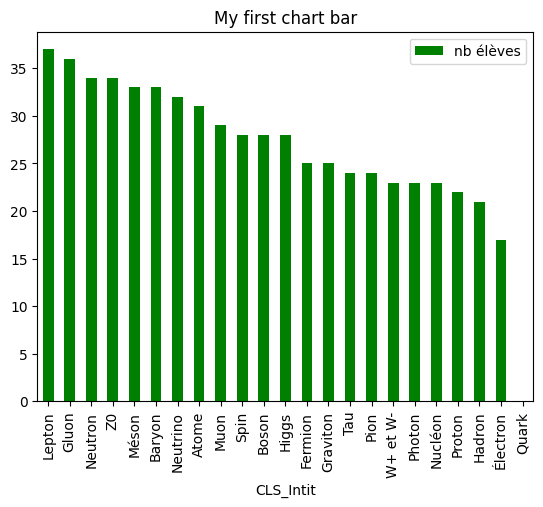

In [34]:
diagramme = df_donnees.plot(kind='bar', y='nb élèves', color='green', title='My first chart bar')

Le résultat obtenu devrait ressembler à ceci :

![diagBarres.png](images6/diagBarres.png) 

__Exercice 1.4.__  Créer un dataframe `df_donneesBis`, à partir du dataframe _df_eleveBis_, permettant d'avoir le nombre d'élèves de toutes les classes dont l'intitulé contient la lettre "i".

Créer un diagramme circulaire (incluant le pourcentage que représente chaque secteur) à partir du dataframe _df_donneesBis_. 

<Axes: title={'center': 'My first pie chart'}>

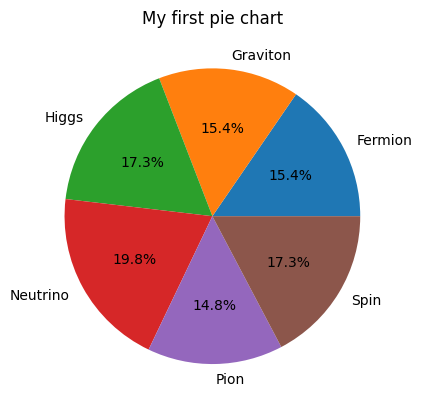

In [14]:
df_donneesBis = df_elevesBis[df_elevesBis['CLS_Intit'].str.contains('i', case=False, na=False)]
df_donneesBis = df_filtre.groupby('CLS_Intit').size().to_frame(name='nb élèves')

df_donneesBis.plot(kind='pie', y='nb élèves', title='My first pie chart',autopct='%1.1f%%',legend=False)

Le résultat obtenu devrait ressembler à ceci :

![diagCirculaire.png](images6/diagCirculaire.png) 

# 2e partie : Compteurs de passages de vélos à Bordeaux

Cette partie du notebook est inspirée du cours de Lino Galiana dispensé à l'[ENSAE](https://linogaliana-teaching.netlify.app/course/). La visualisation se fera avec des données OpenData de Bordeaux Métropole qui recense le nombre de passages de deux-roues en certains points de la métropole (données de 2021).

__Exercice 2.1.__ Charger le fichier *donnees6/pc_captv_p_histo_heure.csv* dans un dataframe `df_velo`, en afficher les 2 premières lignes et les examiner...

In [10]:
df_velo = pd.read_csv("donnees6/pc_captv_p_histo_heure.csv", sep=';')
df_velo.head(2)

,Date et heure de comptage,gid,ident,zone,type,comptage_5m,Geo Point,cdate,libelle
0,2021-05-04T11:00:00+02:00,2443,Z901CT6,901.0,BOUCLE,27.0,"44.8328178,-0.598687",2021-04-28T12:57:13+02:00,Boulevard Antoine Gautier vers rue Berruer
1,2021-05-04T13:00:00+02:00,2443,Z901CT6,901.0,BOUCLE,36.0,"44.8328178,-0.598687",2021-04-28T12:57:13+02:00,Boulevard Antoine Gautier vers rue Berruer


La "partie gauche" du résultat obtenu devrait ressembler à ceci :

![dfVelo.png](images6/dfVelo.png) 

Créer un dataframe `df_velo_moyenne` donnant, pour chaque capteur (identifié par la colonne _ident_), la moyenne du nombre de passages relevés (donnés par la colonne _comptage_5m_), et en afficher les 3 dernière lignes.

In [15]:
df_velo_moyenne = df_velo.groupby('ident')[['comptage_5m']].mean()
df_velo_moyenne = df_velo_moyenne.rename(columns={'comptage_5m': 'moyNbVelos'})
df_velo_moyenne.tail(3)

,moyNbVelos
ident,
Z901CT7,37.645392
Z904CT4,10.205371
Z904CT5,17.607267


Le résultat obtenu devrait ressembler à ceci :

![moyNbVelos.png](images6/moyNbVelos.png) 

Produire un diagramme à barres (horizontales) à partir du dataframe _df_moyenne_velo_ pour les 10 compteurs ayant la moyenne la plus élevée.

<Axes: ylabel='ident'>

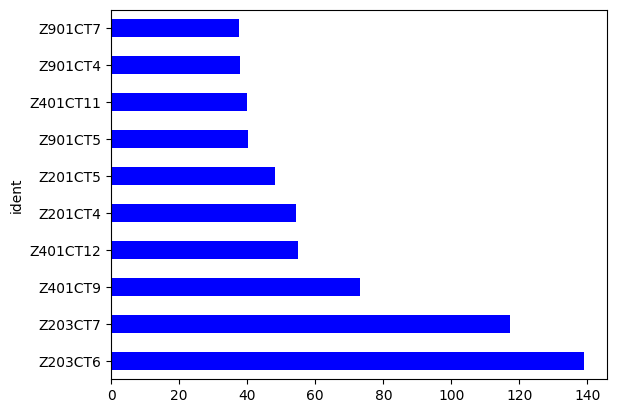

In [18]:
df_velo_moyenne.nlargest(10, 'moyNbVelos').plot(kind='barh', y='moyNbVelos', color='blue', legend=False)

Le résultat obtenu devrait ressembler à ceci :

![diagBarresMoyennes.png](images6/diagBarresMoyennes.png) 

__Exercice 2.2.__ Créer un dataframe `df_Z203CT6`, à partir du dataframe _df_velo_, contenant toutes les données relatives au capteur dont l'indentifiant est _Z203CT6_ ayant été relevées le 21 décembre 2021, trié par _Date et heure de comptage_ et en afficher le contenu (24 lignes, 9 colonnes --> voir la propriété _pandas.DataFrame.shape_.)

On pourra utiliser avec profit la fonction [*pandas.Series.str.contains*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.contains.html)

In [20]:
df_Z203CT6 = df_velo[(df_velo['ident'] == 'Z203CT6') & (df_velo['Date et heure de comptage'].str.contains('2021-12-21', na=False))]
df_Z203CT6 = df_Z203CT6.sort_values(by='Date et heure de comptage')
df_Z203CT6

,Date et heure de comptage,gid,ident,zone,type,comptage_5m,Geo Point,cdate,libelle
263608,2021-12-21T00:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,18.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
263610,2021-12-21T01:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,6.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
12665,2021-12-21T02:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,5.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
12666,2021-12-21T03:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,7.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
12667,2021-12-21T04:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,13.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
263612,2021-12-21T05:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,10.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
12668,2021-12-21T06:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,29.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
12669,2021-12-21T07:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,91.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
68907,2021-12-21T08:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,319.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim
68908,2021-12-21T09:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,262.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim


Le résultat obtenu devrait commencer ainsi :

![Z203CT6.png](images6/Z203CT6.png) 

Créer un dataframe `df_courbe`, à partir du dataframe _df_Z203CT6_, en y rajoutant une colonne `Heure` contenant l'heure (au format _hh:mm_) extraite de la colonne _Horodate_, et en afficher les deux premières lignes.

Possiblement utile, à vous de voir : 
1. Si *S* est une série et *df* un dataframe, *df['New'] = S* rajoute une colonne nommée *New* au dataframe *df*.
2. Si *S* est une série, ou une colonne d'un dataframe, *S.str[2:6]* produit la série composée des sous-chaînes allant du 3e au 6e caractère des élément de *S*...

In [23]:
df_Z203CT6['Heure'] = df_Z203CT6['Date et heure de comptage'].str[11:16]
df_courbe = df_Z203CT6
df_courbe.head(2)

,Date et heure de comptage,gid,ident,zone,type,comptage_5m,Geo Point,cdate,libelle,Heure
263608,2021-12-21T00:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,18.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim,00:00
263610,2021-12-21T01:00:00+01:00,2447,Z203CT6,203.0,BOUCLE,6.0,"44.8372518,-0.5648169",2021-04-28T12:57:13+02:00,Pont de Pierre vers Bir Hakeim,01:00


La "partie droite" du résultat obtenu devrait ressembler à ceci :

![dfCourbe.png](images6/dfCourbe.png) 

Produire une courbe à partir du dataframe _df_courbe_, donnant le nombre de passages de vélos relevés par heure au cours de la journée du 21 décombre 2021.

<Axes: xlabel='Heure'>

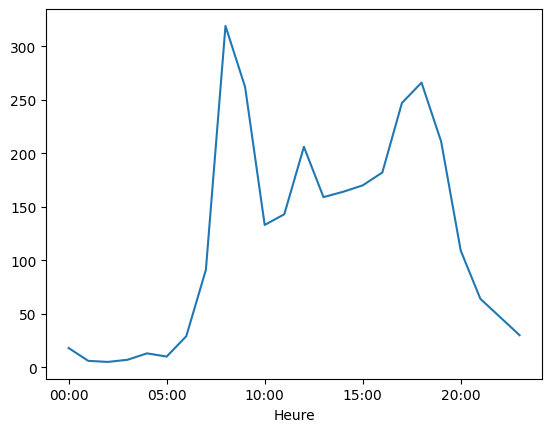

In [25]:
df_courbe.plot(kind='line',x='Heure', y='comptage_5m',legend=False)

Le résultat obtenu devrait ressembler à ceci :

![courbeNbPassages.png](images6/courbeNbPassages.png) 

# 3e partie : Allons plus loin, et utilisons la bibliothèque seaborn

Comme les graphiques produits par _pandas_ suivent la logique très flexible
de _matplotlib_, il est possible de les "customiser". Cependant, c'est
souvent beaucoup de travail et il peut être préférable de directement
utiliser la bibliothèque _seaborn_, qui offre quelques arguments prêts à l'emploi.

Pour illustrer cela, nous allons repartir des deux dataframes précédents créés pour générer des graphiques, _df_moyenne_velo_ et _df_courbe_.

Commençons par l'import classique de seaborn :

In [ ]:
import seaborn as sns

__Exercice supplémentaire S1.__ Il y a plusieurs façons de construire un diagramme à barres (*bar plot*) avec *seaborn*. La plus flexible, c'est-à-dire celle qui permet le mieux d'interagir avec *matplotlib*, est via la fonction *[seaborn.catplot](https://seaborn.pydata.org/generated/seaborn.catplot.html)*.

__S1.1.__ Réinitialiser l'index du dataframe _df_moyenne_velo_ pour avoir une colonne *ident* ('ident' étant actuellement l'index du dataframe, on aurait une erreur avec *seaborn* : "Could not interpret input 'ident'")


__S1.2__. Refaire le graphique de l'exercice 2.1 avec la fonction *catplot* de *seaborn*. Pour
contrôler la taille du graphique vous pouvez utiliser les arguments *height* et
*aspect*.

Le résultat obtenu pourrait ressembler à ceci :

![catplotMoy.png](images6/catplotMoy.png) 

__S1.3.__ Ajouter les titres des axes et le titre du graphique pour le premier graphique


Le résultat obtenu pourrait ressembler à ceci :

![catplotMoy2.png](images6/catplotMoy2.png) 

__S1.4.__ Refaites l'exercice en utilisant la fonction *[sns.barplot](https://seaborn.pydata.org/generated/seaborn.barplot.html)*.

Le résultat obtenu pourrait ressembler à ceci :

![barplotMoy.png](images6/barplotMoy.png) 

__S1.5.__ Essayez de colorer en rouge l'axe des abscisses. Vous pouvez pré-définir un
style avec : *sns.set_style("ticks", {"xtick.color": "red"})*

Le résultat obtenu pourrait ressembler à ceci :

![barplotMoyRed.png](images6/barplotMoyRed.png) 

__Exercice supplémentaire S2.__ Toujours avec *seaborn*, produire au moins deux graphiques (par exemple une courbe à points et un diagramme à barres) donnant les moyennes mensuelles du nombre de passages relevés sur les 12 mois de l'année 2021.

Voici par exemple une courbe et un diagramme à barres :

![courbeSuppl.png](images6/courbeSuppl.png) 

![diagSuppl.png](images6/diagSuppl.png) 